In [51]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

### Step 1. Upload yaml file data

In [52]:
with open('data3/books.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)

In [53]:
books_df = pd.DataFrame(data)
print(books_df)

       :id                                             :title  \
0    21778                         Call of Duty: World at War   
1    21374                                WarioWare: Touched!   
2    21457             Titanic: Music from the Motion Picture   
3    21881  Flashdance: Original Soundtrack from the Motio...   
4    21446                                              Riot!   
..     ...                                                ...   
757  22033                                               Heat   
758  21814                                      The Lion King   
759  21548                Shadow Tactics: Blade of the Shogun   
760  21990                                 Fear and Trembling   
761  21842                               Dulce et Decorum Est   

                                  :author               :genre  \
0                            Elmer Parker           Mythopoeia   
1                       Ms. Kami Prosacco            Mythology   
2                    

### Step 2. Data preparation for yaml file

#### Step 2.1. Columns cleaning

In [54]:
books_df.columns = books_df.columns.str.replace(":", "", regex=False)

In [55]:
books_df.head()

,id,title,author,genre,publisher,year
0,21778,Call of Duty: World at War,Elmer Parker,Mythopoeia,Orion Books,2003
1,21374,WarioWare: Touched!,Ms. Kami Prosacco,Mythology,St. Martin's Press,1951
2,21457,Titanic: Music from the Motion Picture,Zoila Christiansen,Historical fiction,"Farrar, Straus & Giroux",2009
3,21881,Flashdance: Original Soundtrack from the Motio...,"Joseph Raynor, Ja Ankunding II",Metafiction,Pen and Sword Books,2024
4,21446,Riot!,Louanne Cruickshank,Mystery,Bellevue Literary Press,1987


#### Step 2.2. Type conversion in the <i>title</i> and <i>author</i> columns

In [56]:
books_df["title"] = books_df["title"].astype("string")
books_df["author"] = books_df["author"].astype("string")

#### Step 2.3. Cleaning and conversion <i>year</i> column

In [57]:
mask = pd.to_numeric(books_df["year"], errors="coerce").isna() & books_df["year"].notna()
books_df.loc[mask, "year"].unique()

array(['\t', ' ', '-', 'NULL', ''], dtype=object)

In [58]:
books_df.loc[mask, ["title", "year"]]

,title,year
36,Postern of Fate,\t
176,In Dubious Battle,\t
199,Pac-Man,
230,Beneath the Bleeding,-
373,Appetite for Destruction,NULL
457,Bicycle Thieves,NULL
604,Spirited Away,NULL
700,Once Upon a Time in America,


In [59]:
books_df["year"] = books_df["year"].astype("string").str.strip()

In [60]:
books_df["year"] = pd.to_numeric(books_df["year"], errors="coerce").astype("Int16")

#### Step 2.4. Type conversion in the <i>publisher</i> column

In [61]:
books_df["publisher"].nunique()

246

In [62]:
books_df["publisher"].nunique(dropna=False)

247

In [63]:
books_df["publisher"].value_counts(dropna=False)

publisher
Pen and Sword Books       12
Gefen Publishing House    10
                           8
Adis International         8
HarperCollins              7
                          ..
Virgin Publishing          1
Kensington Books           1
Kogan Page                 1
Peace Hill Press           1
Brill                      1
Name: count, Length: 247, dtype: int64

In [64]:
books_df["publisher"] = (
    books_df["publisher"]
    .astype("string")
    .str.strip()
    .replace(["", "NULL", "-"], pd.NA)
    .astype("category")
)

In [65]:
books_df["publisher"].dtype

CategoricalDtype(categories=['Academic Press', 'Ace Books', 'Addison-Wesley',
                  'Adis International', 'Airiti Press', 'Allen Ltd',
                  'Andrews McMeel Publishing', 'André Deutsch', 'Anova Books',
                  'Anvil Press Poetry',
                  ...
                  'Verso Books', 'Victor Gollancz Ltd', 'Viking Press',
                  'Vintage Books', 'Virago Press', 'Virgin Publishing',
                  'Voyager Books', 'Zed Books', 'Ziff Davis Media',
                  'Zondervan'],
, ordered=False, categories_dtype=string)

In [66]:
books_df["publisher"].nunique(dropna=False)

242

#### Step 2.5. Type conversion in the <i>genre</i> column

In [67]:
books_df["genre"].nunique(dropna=False)

30

In [68]:
books_df["genre"].value_counts(dropna=False).tail(30)

genre
Science fiction            40
Realistic fiction          36
Comic/Graphic Novel        36
Legend                     35
Horror                     32
Fantasy                    32
Speech                     32
Fable                      32
Narrative nonfiction       29
Essay                      29
Classic                    29
Mythopoeia                 28
Mystery                    28
Historical fiction         26
Metafiction                26
Mythology                  24
Fiction in verse           24
Reference book             23
Crime/Detective            23
Fairy tale                 22
Fanfiction                 22
Tall tale                  21
Fiction narrative          21
Folklore                   19
Textbook                   17
Suspense/Thriller          16
Humor                      16
Short story                15
Biography/Autobiography    15
Western                    14
Name: count, dtype: int64

In [69]:
books_df["genre"] = books_df["genre"].astype("category")

In [70]:
books_df["genre"].dtype

CategoricalDtype(categories=['Biography/Autobiography', 'Classic', 'Comic/Graphic Novel',
                  'Crime/Detective', 'Essay', 'Fable', 'Fairy tale',
                  'Fanfiction', 'Fantasy', 'Fiction in verse',
                  'Fiction narrative', 'Folklore', 'Historical fiction',
                  'Horror', 'Humor', 'Legend', 'Metafiction', 'Mystery',
                  'Mythology', 'Mythopoeia', 'Narrative nonfiction',
                  'Realistic fiction', 'Reference book', 'Science fiction',
                  'Short story', 'Speech', 'Suspense/Thriller', 'Tall tale',
                  'Textbook', 'Western'],
, ordered=False, categories_dtype=str)

#### Step 2.5. Checking data 

In [71]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         762 non-null    int64   
 1   title      762 non-null    string  
 2   author     762 non-null    string  
 3   genre      762 non-null    category
 4   publisher  746 non-null    category
 5   year       752 non-null    Int16   
dtypes: Int16(1), category(2), int64(1), string(2)
memory usage: 58.2 KB


### Step 3. Upload parquet file

In [72]:
orders_df = pd.read_parquet("data3/orders.parquet", engine="fastparquet")

In [73]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,80941,47864,21550,1,67.0 €,2025-01-11 09:50:11 PM,
1,81245,47864,22052,2,EUR26.99,2024-03-27T07:46:55.055,
2,78477,48918,21367,1,30 $,"11:17:51 PM, 29-JUN-2025",
3,86303,48092,21724,1,18 $,09:29;11/06/24,None
4,81990,48418,21441,1,USD 24.99,2024-09-16;03:05:39 pm,None


In [74]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          8933 non-null   int64 
 1   user_id     8933 non-null   int64 
 2   book_id     8933 non-null   int64 
 3   quantity    8933 non-null   int32 
 4   unit_price  8933 non-null   object
 5   timestamp   8933 non-null   object
 6   shipping    6721 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 453.8+ KB


### Step 4. Data preparation for <i>parquet</i> file

#### Step 4.1. Type conversion in the <i>timestamp</i> column

In [75]:
clean_ts = (
    orders_df["timestamp"]
    .astype("string")
    .str.strip()
    .str.replace("A.M.", "AM", regex=False)
    .str.replace("P.M.", "PM", regex=False)
    .str.replace(";", " ", regex=False)
    .str.replace(",", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

orders_df["timestamp_parsed"] = pd.to_datetime(
    clean_ts,
    format="mixed",
    errors="coerce",
    dayfirst=True
)

In [76]:
orders_df["date"] = orders_df["timestamp_parsed"].dt.normalize()

In [77]:
bad_mask = orders_df["timestamp_parsed"].isna() & orders_df["timestamp"].notna()
orders_df.loc[bad_mask, "timestamp"].unique()

array([], dtype=object)

In [78]:
orders_df.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,timestamp_parsed,date
0,80941,47864,21550,1,67.0 €,2025-01-11 09:50:11 PM,,2025-11-01 21:50:11.000,2025-11-01
1,81245,47864,22052,2,EUR26.99,2024-03-27T07:46:55.055,,2024-03-27 07:46:55.055,2024-03-27
2,78477,48918,21367,1,30 $,"11:17:51 PM, 29-JUN-2025",,2025-06-29 23:17:51.000,2025-06-29
3,86303,48092,21724,1,18 $,09:29;11/06/24,None,2024-06-11 09:29:00.000,2024-06-11
4,81990,48418,21441,1,USD 24.99,2024-09-16;03:05:39 pm,None,2024-09-16 15:05:39.000,2024-09-16


#### Step 4.2. Type conversion in the <i>unit price</i> column

In [79]:
price_raw = (
    orders_df["unit_price"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", "", regex=True)
)

orders_df["unit_price_currency"] = (
    price_raw
    .str.extract(r"(USD|EUR|\$|€)", expand=False)
    .replace({"$": "USD", "€": "EUR"})
)

amount_str = (
    price_raw
    .str.replace(r"^(\d+)(\$|€)(\d+)¢$", r"\1.\3", regex=True)
    .str.replace(r"^(USD|EUR|\$|€)(\d+)¢(\d+)$", r"\2.\3", regex=True)
    .str.replace(r"USD|EUR|\$|€", "", regex=True)
    .str.replace("¢", ".", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(r"[^\d.]", "", regex=True)
)

orders_df["unit_price_value"] = pd.to_numeric(amount_str, errors="coerce")

In [80]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].head(20)

,unit_price,unit_price_currency,unit_price_value
0,67.0 €,EUR,67.0
1,EUR26.99,EUR,26.99
2,30 $,USD,30.0
3,18 $,USD,18.0
4,USD 24.99,USD,24.99
5,41.50$,USD,41.5
6,19.99 $,USD,19.99
7,61.99 $,USD,61.99
8,69.5$,USD,69.5
9,66.99 €,EUR,66.99


In [81]:
orders_df[["unit_price", "unit_price_currency", "unit_price_value"]].tail(20)

,unit_price,unit_price_currency,unit_price_value
8913,$62.25,USD,62.25
8914,69.00 USD,USD,69.0
8915,$71.0,USD,71.0
8916,USD42.25,USD,42.25
8917,37.0 $,USD,37.0
8918,€49¢50,EUR,49.5
8919,$ 13.99,USD,13.99
8920,27€75¢,EUR,27.75
8921,42.99USD,USD,42.99
8922,54.99 USD,USD,54.99


In [82]:
bad_mask = orders_df["unit_price_value"].isna() | orders_df["unit_price_currency"].isna()
orders_df.loc[bad_mask, "unit_price"].drop_duplicates()

Series([], Name: unit_price, dtype: object)

#### Step 4.3. Currency conversion in the <i>unit price</i> column

In [83]:
mask = (orders_df["unit_price_currency"] == "EUR")

orders_df.loc[mask, "unit_price_value"] = (
    orders_df.loc[mask, "unit_price_value"] * 1.2
).round(2)

orders_df.loc[mask, "unit_price_currency"] = "USD"

In [84]:
orders_df["unit_price_currency"].value_counts(dropna=False)

unit_price_currency
USD    8933
Name: count, dtype: int64[pyarrow]

In [85]:
orders_df[["unit_price_currency", "unit_price_value"]].tail(20)

,unit_price_currency,unit_price_value
8913,USD,62.25
8914,USD,69.0
8915,USD,71.0
8916,USD,42.25
8917,USD,37.0
8918,USD,59.4
8919,USD,13.99
8920,USD,33.3
8921,USD,42.99
8922,USD,54.99


#### Step 4.4. Adding a <i>paid price</i> column

In [86]:
orders_df["paid_price"] = orders_df["quantity"] * orders_df["unit_price_value"]

#### Step 4.5. Checking data

In [87]:
orders_df = orders_df.drop(columns=["timestamp", "timestamp_parsed", "unit_price"])

In [88]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   8933 non-null   int64         
 1   user_id              8933 non-null   int64         
 2   book_id              8933 non-null   int64         
 3   quantity             8933 non-null   int32         
 4   shipping             6721 non-null   object        
 5   date                 8933 non-null   datetime64[us]
 6   unit_price_currency  8933 non-null   string        
 7   unit_price_value     8933 non-null   Float64       
 8   paid_price           8933 non-null   Float64       
dtypes: Float64(2), datetime64[us](1), int32(1), int64(3), object(1), string(1)
memory usage: 637.0+ KB


In [89]:
orders_df.head()

,id,user_id,book_id,quantity,shipping,date,unit_price_currency,unit_price_value,paid_price
0,80941,47864,21550,1,,2025-11-01,USD,80.4,80.4
1,81245,47864,22052,2,,2024-03-27,USD,32.39,64.78
2,78477,48918,21367,1,,2025-06-29,USD,30.0,30.0
3,86303,48092,21724,1,None,2024-06-11,USD,18.0,18.0
4,81990,48418,21441,1,None,2024-09-16,USD,24.99,24.99


### Step 5. Upload csv file

In [90]:
users_df = pd.read_csv("data3/users.csv")

In [91]:
users_df.head(5)

,id,name,address,phone,email
0,47856,Tammie Mayer,"Apt. 371 1875 Gusikowski Stravenue, Moenland, ...",163.212.2656,maire.larson@runolfsdottir-mclaughlin.example
1,49394,Evia Yost,"22610 Mildred Green, Pagacbury, AZ 19393-2103",778.926.6707,byron@johnston.test
2,48386,Margery Gorczany,"Apt. 884 349 Renner Lane, East Darren, NC 30837",992 375 5021,cletus@baumbach.test
3,49547,Edris Kshlerin,"Suite 498 24711 Bechtelar Extensions, Ryanvill...",747.537.2209,leonore@gleason.test
4,50512,Meghan Thiel,"125 Rodger Drive, Rogahnborough, VT 96988-4596",(631) 765-7676,cristine@bayer.test


In [92]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3466 entries, 0 to 3465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       3466 non-null   int64
 1   name     3466 non-null   str  
 2   address  3344 non-null   str  
 3   phone    3466 non-null   str  
 4   email    3466 non-null   str  
dtypes: int64(1), str(4)
memory usage: 475.3 KB


### Step 6. Data preparation for csv file

#### Step 6.1. Formatting <i>phone</i> column

In [93]:
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)

users_df["phone_clean"] = phones
users_df["phone_formatted"] = phones.str.replace(
    r"^(\d{3})(\d{3})(\d{4})$",
    r"(\1) \2-\3",
    regex=True
)

In [94]:
# To check "broken" phones
phones = users_df["phone"].astype("string").str.replace(r"\D", "", regex=True)
bad_mask = phones.str.len() != 10
users_df.loc[bad_mask, "phone"].drop_duplicates()

Series([], Name: phone, dtype: str)

In [95]:
users_df["phone"] = users_df["phone_formatted"]
users_df = users_df.drop(columns=["phone_clean", "phone_formatted"])

#### Step 6.2. Checking data

In [96]:
users_df.head()

,id,name,address,phone,email
0,47856,Tammie Mayer,"Apt. 371 1875 Gusikowski Stravenue, Moenland, ...",(163) 212-2656,maire.larson@runolfsdottir-mclaughlin.example
1,49394,Evia Yost,"22610 Mildred Green, Pagacbury, AZ 19393-2103",(778) 926-6707,byron@johnston.test
2,48386,Margery Gorczany,"Apt. 884 349 Renner Lane, East Darren, NC 30837",(992) 375-5021,cletus@baumbach.test
3,49547,Edris Kshlerin,"Suite 498 24711 Bechtelar Extensions, Ryanvill...",(747) 537-2209,leonore@gleason.test
4,50512,Meghan Thiel,"125 Rodger Drive, Rogahnborough, VT 96988-4596",(631) 765-7676,cristine@bayer.test


In [97]:
users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3466 entries, 0 to 3465
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3466 non-null   int64 
 1   name     3466 non-null   str   
 2   address  3344 non-null   str   
 3   phone    3466 non-null   string
 4   email    3466 non-null   str   
dtypes: int64(1), str(3), string(1)
memory usage: 480.8 KB


### Step 7. Task 1 - top 5 days by revenue

In [98]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("daily_revenue", ascending=False)
)

top_5_days = daily_revenue_df.head(5)
print(top_5_days)

          date  daily_revenue
301 2024-11-16         3688.2
297 2024-11-12        3411.99
377 2025-01-31        3341.99
280 2024-10-26        3127.92
343 2024-12-28         2933.7


### Step 8. Task 2 - unique users number

In [99]:
df = users_df.copy()

for col in ["name", "address", "phone"]:
    df[col] = df[col].astype("string").str.strip().str.lower()

for col in ["name", "address", "phone"]:
    df[col] = df[col].replace(["", "nan", "none"], pd.NA)

parent = list(range(len(df)))

In [100]:
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

In [101]:
doubles = [
    ["name", "address"],
    ["name", "phone"],
    ["address", "phone"],
]

In [102]:
for cols in doubles:
    temp = df.reset_index().dropna(subset=cols)
    grouped = temp.groupby(cols)["index"].apply(list)

    for ids in grouped:
        first = ids[0]
        for other in ids[1:]:
            union(first, other)

real_unique_users = len({find(i) for i in range(len(df))})
print(real_unique_users)

3290


### Step 9. Task 3 - unique sets of authors

In [103]:
author_sets = (
    books_df["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

unique_author_sets_count = author_sets.nunique()
print(unique_author_sets_count)

268


### Step 10. Task 4 - the most popular author

In [104]:
books_tmp = books_df.copy()

books_tmp["author_set"] = (
    books_tmp["author"]
    .astype("string")
    .str.lower()
    .str.split(",")
    .apply(lambda authors: tuple(sorted(a.strip() for a in authors if a.strip())))
)

author_set_sales = (
    orders_df
    .merge(books_tmp[["id", "author_set"]], left_on="book_id", right_on="id", how="left")
    .groupby("author_set", as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "sold_book_count"})
    .sort_values("sold_book_count", ascending=False)
)

print(author_set_sales.head(1))

                                author_set  sold_book_count
65  (coy streich, keeley hand, lela emard)              159


### Step 11. Task 5 - top customers

In [105]:
users_df["customer_group"] = [find(i) for i in range(len(df))]

In [106]:
user_group_map = users_df[["id", "customer_group"]]

customer_spending = (
    orders_df
    .merge(user_group_map, left_on="user_id", right_on="id", how="left")
    .groupby("customer_group", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "total_spending"})
    .sort_values("total_spending", ascending=False)
)

top_group = customer_spending.iloc[0]["customer_group"]
top_total_spending = customer_spending.iloc[0]["total_spending"]

top_customer_user_ids = users_df.loc[
    users_df["customer_group"] == top_group, "id"
].tolist()

print("Top customer group:", top_group)
print("Total spending:", top_total_spending)
print("All related user_id values:", top_customer_user_ids)

Top customer group: 527.0
Total spending: 1207.48
All related user_id values: [49715, 50963]


In [107]:
top_customer_records = users_df.loc[
    users_df["customer_group"] == top_group,
    ["id", "name", "address", "email", "phone"]
]

print(top_customer_records)

         id              name                                         address  \
527   49715       Tony Sawayn  Apt. 755 91534 Edgar Dale, Gradyland, AL 98124   
3063  50963  Long Bogisich IV  Apt. 755 91534 Edgar Dale, Gradyland, AL 98124   

                      email           phone  
527   robby@padberg.example  (526) 708-1955  
3063  robby@padberg.example  (526) 708-1955  


### Step 12. Task 6 - line chart of daily revenue

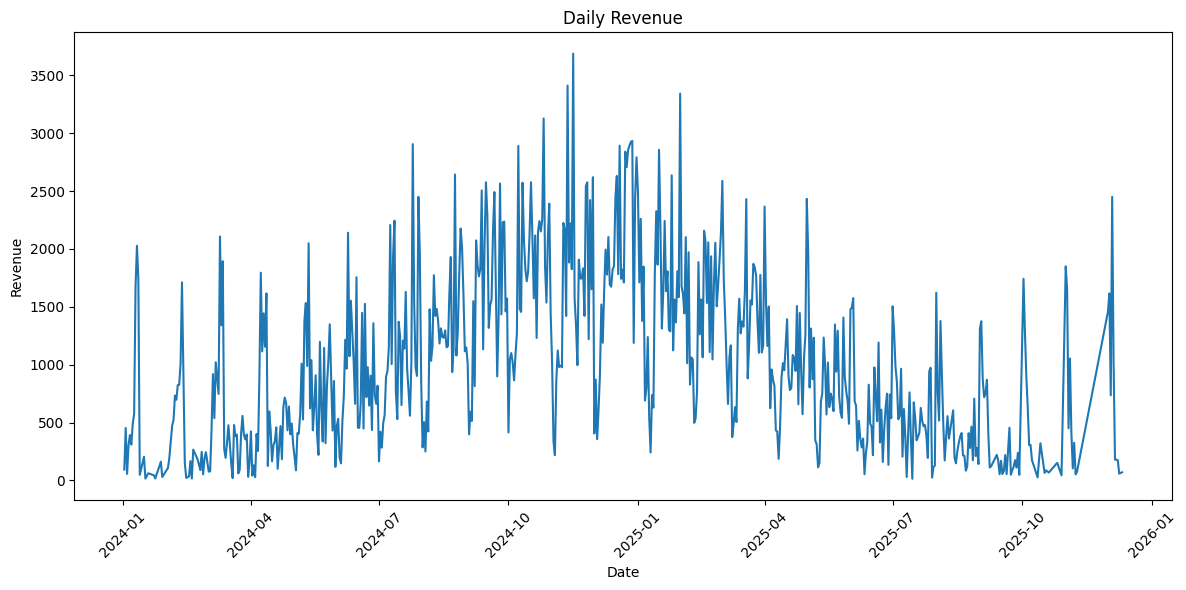

In [108]:
daily_revenue_df = (
    orders_df
    .groupby("date", as_index=False)["paid_price"]
    .sum()
    .rename(columns={"paid_price": "daily_revenue"})
    .sort_values("date")
)

plt.figure(figsize=(12, 6))
plt.plot(daily_revenue_df["date"], daily_revenue_df["daily_revenue"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [110]:
daily_revenue_df.to_csv("daily_revenue_data_3.csv", index=False)